In [1]:
import os
import scanpy as sc
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import warnings

import moscot as mt
import moscot.plotting as mpl
from moscot.problems.time import TemporalProblem


In [37]:
import os
os.chdir("/projects/bgdb/asachan/methods/OT_FM")  # adjust path if needed
from utils import *

In [2]:
plt.rcParams["legend.scatterpoints"] = 1
sc.set_figure_params(scanpy=True, dpi=80, dpi_save=200)

warnings.simplefilter("ignore", UserWarning)
warnings.simplefilter("ignore", FutureWarning)

#### Load and combine scRNA and scATAC-seq data (multiome - so cell barcodes are shared)

In [3]:
rna_path = '/projects/bgdb/asachan/datasets/Bcell_in_vitro_human/stream_input_filtered_cells_v7.h5ad'
atac_path = '/projects/bgdb/asachan/datasets/Bcell_in_vitro_human/adata_aggregated_peak.leiden.h5ad'

In [4]:
rna_adata = sc.read_h5ad(rna_path)
rna_adata

AnnData object with n_obs × n_vars = 28494 × 3018
    obs: 'cell_type_major', 'n_genes', 'n_genes_by_counts', 'total_counts', 'total_counts_mt', 'pct_counts_mt', 'topic_0', 'topic_1', 'topic_2', 'topic_3', 'topic_4', 'topic_5', 'topic_6', 'topic_7', 'topic_8', 'topic_9', 'topic_10', 'topic_11', 'topic_12', 'topic_13', 'topic_14', 'topic_15', 'topic_16', 'topic_17', 'topic_18', 'topic_19', 'topic_20', 'topic_21', 'topic_22', 'topic_23', 'topic_24', 'topic_25', 'topic_26', 'topic_27', 'topic_28', 'topic_29', 'topic_30', 'topic_31', 'leiden', 'sub_cell_type'
    var: 'gene_ids', 'feature_types', 'genome', 'n_cells', 'mt', 'n_cells_by_counts', 'mean_counts', 'pct_dropout_by_counts', 'total_counts', 'highly_variable', 'means', 'dispersions', 'dispersions_norm', 'mean', 'std'
    uns: 'DM_EigenValues', 'cell_type_major_colors', 'hvg', 'leiden', 'leiden_colors', 'log1p', 'neighbors', 'pca', 'sub_cell_type_colors', 'topic_dendogram', 'umap'
    obsm: 'DM_EigenVectors', 'X_joint_umap_features',

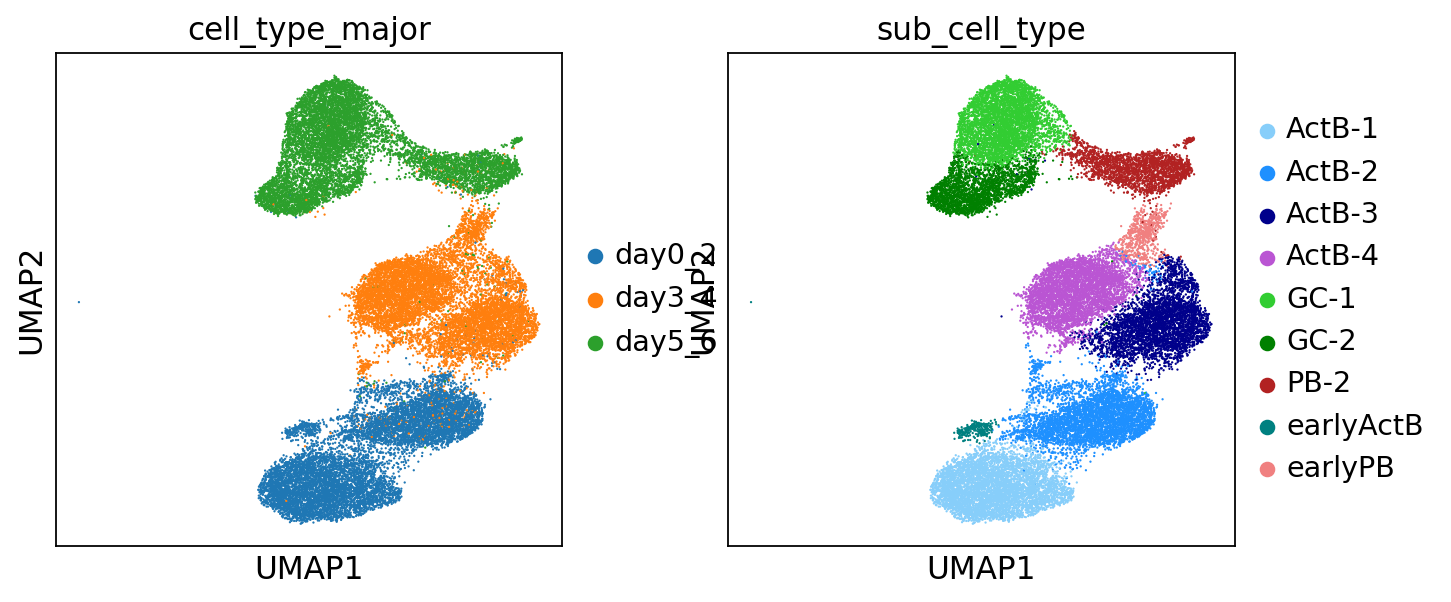

In [5]:
sc.pl.umap(rna_adata, color=['cell_type_major', 'sub_cell_type'])

In [6]:
rna_adata.obs['cell_type_major']

AAACAGCCAAGCCACT-3    day5_6
AAACAGCCAAGGTGCA-1    day0_2
AAACAGCCAAGTTATC-1    day0_2
AAACAGCCAATAGCCC-1    day0_2
AAACAGCCAGTTAGCC-1    day0_2
                       ...  
TTTGTTGGTTTACGTC-1    day0_2
TTTGTTGGTTTAGTCC-1    day0_2
TTTGTTGGTTTATGGG-2    day3_4
TTTGTTGGTTTCCTCC-3    day5_6
TTTGTTGGTTTGAGGC-2    day3_4
Name: cell_type_major, Length: 28494, dtype: category
Categories (3, str): ['day0_2', 'day3_4', 'day5_6']

In [7]:
atac_adata = sc.read_h5ad(atac_path)
atac_adata

AnnData object with n_obs × n_vars = 32418 × 191255
    obs: 'cell_type_major', 'topic_0', 'topic_1', 'topic_2', 'topic_3', 'topic_4', 'topic_5', 'topic_6', 'topic_7', 'topic_8', 'topic_9', 'topic_10', 'topic_11', 'topic_12', 'topic_13', 'topic_14', 'topic_15', 'topic_16', 'topic_17', 'topic_18', 'topic_19', 'topic_20', 'topic_21', 'cell_index', 'leiden_joint'
    var: 'gene_ids', 'feature_types', 'genome'
    uns: 'topic_dendogram'
    obsm: 'X_joint_umap_features', 'X_topic_compositions', 'X_umap_features'
    varm: 'topic_feature_activations', 'topic_feature_compositions'
    layers: 'counts'

In [8]:
atac_adata.var

,gene_ids,feature_types,genome
chr1:9809-10677,chr1:9809-10677,Peaks,GRCh38
chr1:28988-29868,chr1:28988-29868,Peaks,GRCh38
chr1:180722-180992,chr1:180722-180992,Peaks,GRCh38
chr1:181093-181802,chr1:181093-181802,Peaks,GRCh38
chr1:267555-268452,chr1:267555-268452,Peaks,GRCh38
...,...,...,...
KI270713.1:29710-30533,KI270713.1:29710-30533,Peaks,GRCh38
KI270713.1:31281-32210,KI270713.1:31281-32210,Peaks,GRCh38
KI270713.1:32672-33147,KI270713.1:32672-33147,Peaks,GRCh38
KI270713.1:33255-33832,KI270713.1:33255-33832,Peaks,GRCh38


In [9]:
# check shared cells
shared = rna_adata.obs_names.intersection(atac_adata.obs_names)
print("shared cells:", len(shared))

shared cells: 28494


In [10]:
atac_adata = atac_adata[shared].copy()

# Import mudata

In [11]:
import muon as mu

mdata = mu.read_h5mu('/projects/bgdb/asachan/datasets/Bcell_in_vitro_human/rna_atac_multivi.h5mu')
mdata

MuData object with n_obs × n_vars = 28494 × 194273
  obs:	'_indices', '_scvi_batch', '_scvi_labels'
  var:	'gene_ids', 'feature_types', 'genome'
  uns:	'_scvi_manager_uuid', '_scvi_uuid'
  obsm:	'X_MultiVI'
  2 modalities
    rna:	28494 x 3018
      obs:	'cell_type_major', 'n_genes', 'n_genes_by_counts', 'total_counts', 'total_counts_mt', 'pct_counts_mt', 'topic_0', 'topic_1', 'topic_2', 'topic_3', 'topic_4', 'topic_5', 'topic_6', 'topic_7', 'topic_8', 'topic_9', 'topic_10', 'topic_11', 'topic_12', 'topic_13', 'topic_14', 'topic_15', 'topic_16', 'topic_17', 'topic_18', 'topic_19', 'topic_20', 'topic_21', 'topic_22', 'topic_23', 'topic_24', 'topic_25', 'topic_26', 'topic_27', 'topic_28', 'topic_29', 'topic_30', 'topic_31', 'leiden', 'sub_cell_type'
      var:	'gene_ids', 'feature_types', 'genome', 'n_cells', 'mt', 'n_cells_by_counts', 'mean_counts', 'pct_dropout_by_counts', 'total_counts', 'highly_variable', 'means', 'dispersions', 'dispersions_norm', 'mean', 'std'
      uns:	'DM_EigenValues', 'cell_type_major_colors', 'hvg', 'leiden', 'leiden_colors', 'log1p', 'neighbors', 'pca', 'sub_cell_type_colors', 'topic_dendogram', 'umap'
      obsm:	'DM_EigenVectors', 'X_joint_umap_features', 'X_pca', 'X_topic_compositions', 'X_umap', 'X_umap_features'
      varm:	'PCs', 'topic_feature_activations', 'topic_feature_compositions'
      layers:	'MAGIC_imputed_data', 'counts'
      obsp:	'DM_Kernel', 'DM_Similarity', 'connectivities', 'distances'
    atac:	28494 x 191255
      obs:	'cell_type_major', 'topic_0', 'topic_1', 'topic_2', 'topic_3', 'topic_4', 'topic_5', 'topic_6', 'topic_7', 'topic_8', 'topic_9', 'topic_10', 'topic_11', 'topic_12', 'topic_13', 'topic_14', 'topic_15', 'topic_16', 'topic_17', 'topic_18', 'topic_19', 'topic_20', 'topic_21', 'cell_index', 'leiden_joint'
      var:	'gene_ids', 'feature_types', 'genome'
      uns:	'topic_dendogram'
      obsm:	'X_joint_umap_features', 'X_topic_compositions', 'X_umap_features'
      varm:	'topic_feature_activations', 'topic_feature_compositions'
      layers:	'counts'

In [12]:
X = mdata.obsm["X_MultiVI"]
X.shape

(28494, 11)

In [13]:
common = rna_adata.obs_names.intersection(mdata.obs_names)
assert len(common) == rna_adata.n_obs == mdata.n_obs

rna_adata.obsm["X_MultiVI"] = mdata[rna_adata.obs_names].obsm["X_MultiVI"]


### Cleanup cell states by day

In [14]:
# 'ActB-1',
#  'ActB-2',
#  'ActB-3',
#  'ActB-4',
#  'GC-1',
#  'GC-2',
#  'PB-2',
#  'earlyActB',
#  'earlyPB'
adata_subset = rna_adata[rna_adata.obs['sub_cell_type'] == "PB-2"]

In [15]:
adata_subset.obs['cell_type_major'].value_counts()

cell_type_major
day5_6    2259
day3_4      78
day0_2       8
Name: count, dtype: int64

In [16]:
keep_by_day = {
    "day0_2": ["earlyActB", "ActB-1", "ActB-2"],
    "day3_4": ["ActB-2", "ActB-3", "ActB-4", "earlyPB", "PB-2"],
    "day5_6": ["GC-1", "GC-2", "PB-2"],
}

day_key = "cell_type_major"
ct_key  = "sub_cell_type"

mask = rna_adata.obs.apply(lambda r: r[ct_key] in keep_by_day.get(r[day_key], []), axis=1)

adata_asym = rna_adata[mask].copy()

# cleanup
adata_asym.obs[ct_key] = adata_asym.obs[ct_key].astype("category").cat.remove_unused_categories()
adata_asym.obs[day_key] = adata_asym.obs[day_key].astype("category").cat.remove_unused_categories()

In [17]:
adata_asym

AnnData object with n_obs × n_vars = 28321 × 3018
    obs: 'cell_type_major', 'n_genes', 'n_genes_by_counts', 'total_counts', 'total_counts_mt', 'pct_counts_mt', 'topic_0', 'topic_1', 'topic_2', 'topic_3', 'topic_4', 'topic_5', 'topic_6', 'topic_7', 'topic_8', 'topic_9', 'topic_10', 'topic_11', 'topic_12', 'topic_13', 'topic_14', 'topic_15', 'topic_16', 'topic_17', 'topic_18', 'topic_19', 'topic_20', 'topic_21', 'topic_22', 'topic_23', 'topic_24', 'topic_25', 'topic_26', 'topic_27', 'topic_28', 'topic_29', 'topic_30', 'topic_31', 'leiden', 'sub_cell_type'
    var: 'gene_ids', 'feature_types', 'genome', 'n_cells', 'mt', 'n_cells_by_counts', 'mean_counts', 'pct_dropout_by_counts', 'total_counts', 'highly_variable', 'means', 'dispersions', 'dispersions_norm', 'mean', 'std'
    uns: 'DM_EigenValues', 'cell_type_major_colors', 'hvg', 'leiden', 'leiden_colors', 'log1p', 'neighbors', 'pca', 'sub_cell_type_colors', 'topic_dendogram', 'umap'
    obsm: 'DM_EigenVectors', 'X_joint_umap_features',

In [18]:
# make temporal info numeric
def adapt_time(x):
    if x["cell_type_major"] == "day0_2":
        return 1.5
    if x["cell_type_major"] == "day3_4":
        return 3.5
    if x["cell_type_major"] == "day5_6":
        return 5.5
    raise ValueError

adata_asym.obs["cell_type_major"] = adata_asym.obs.apply(adapt_time, axis=1).astype("category")

In [19]:
# instantiate temporal OT problem
tp0 = TemporalProblem(adata_asym)
tp0 = tp0.prepare(time_key="cell_type_major", joint_attr="X_MultiVI")

In [20]:
import networkx as nx

dfs = {}
batch_column = "cell_type_major"
unique_batches = [1.5, 3.5, 5.5]

# pair wise WOT
for i in range(len(unique_batches) - 1):
    batch1 = unique_batches[i]
    batch2 = unique_batches[i + 1]

    indices = np.where(
        (adata_asym.obs[batch_column] == batch1) | (adata_asym.obs[batch_column] == batch2)
    )[0]
    adata_subset = adata_asym[indices]

    sc.pp.neighbors(adata_subset, use_rep="X_MultiVI", n_neighbors=30)
    G = nx.from_numpy_array(adata_subset.obsp["connectivities"].todense())
    assert nx.is_connected(G)

    # store the kNN graph as a dense pandas df and save it in a dict
    dfs[(batch1, batch2)] = pd.DataFrame(
        index=adata_subset.obs_names,
        columns=adata_subset.obs_names,
        data=adata_subset.obsp["connectivities"].todense().astype("float"),
    )

In [21]:
for (t1, t2) in [(1.5, 3.5), (3.5, 5.5)]:
    prob = tp0[t1, t2]

    expected = prob.adata_src.obs_names.append(prob.adata_tgt.obs_names)  # Index
    Gdf = dfs[(t1, t2)].loc[expected, expected].astype(float)

    prob.set_graph_xy(Gdf, t=100.0)


## Solve OT

In [22]:
# epsilon: entropic regularization strength
tp0 = tp0.solve(epsilon=1e-3, scale_cost="mean", max_iterations=1e7)

INFO     Solving `2` problems                                                                                      
INFO     Solving problem BirthDeathProblem[stage='prepared', shape=(9360, 9111)].                                  


W0311 03:39:03.221477 3898038 sol_gpu_cost_model.cc:102] No SoL config found for device: NVIDIA H200. Using default config.
W0311 03:39:09.391802 3898038 sol_gpu_cost_model.cc:102] No SoL config found for device: NVIDIA H200. Using default config.
W0311 03:39:18.372006 3898038 sol_gpu_cost_model.cc:102] No SoL config found for device: NVIDIA H200. Using default config.
W0311 03:39:20.330160 3898038 sol_gpu_cost_model.cc:102] No SoL config found for device: NVIDIA H200. Using default config.
W0311 03:39:20.604794 3898038 sol_gpu_cost_model.cc:102] No SoL config found for device: NVIDIA H200. Using default config.
W0311 03:39:21.567051 3898038 sol_gpu_cost_model.cc:102] No SoL config found for device: NVIDIA H200. Using default config.
W0311 03:39:21.840600 3898038 sol_gpu_cost_model.cc:102] No SoL config found for device: NVIDIA H200. Using default config.
W0311 03:39:22.770154 3898038 sol_gpu_cost_model.cc:102] No SoL config found for device: NVIDIA H200. Using default config.
W0311 03

INFO     Solving problem BirthDeathProblem[stage='prepared', shape=(9850, 9360)].                                  


W0311 03:41:31.729882 3898038 sol_gpu_cost_model.cc:102] No SoL config found for device: NVIDIA H200. Using default config.
W0311 03:41:31.867879 3898038 sol_gpu_cost_model.cc:102] No SoL config found for device: NVIDIA H200. Using default config.
W0311 03:41:31.917574 3898038 sol_gpu_cost_model.cc:102] No SoL config found for device: NVIDIA H200. Using default config.
W0311 03:41:31.993730 3898038 sol_gpu_cost_model.cc:102] No SoL config found for device: NVIDIA H200. Using default config.
W0311 03:41:32.034321 3898038 sol_gpu_cost_model.cc:102] No SoL config found for device: NVIDIA H200. Using default config.
W0311 03:41:32.219195 3898038 sol_gpu_cost_model.cc:102] No SoL config found for device: NVIDIA H200. Using default config.
W0311 03:41:53.825046 3898038 gemm_fusion_autotuner.cc:1053] Compiling 60 configs for 2 fusions on a single thread.
W0311 03:41:53.830074 3898038 sol_gpu_cost_model.cc:102] No SoL config found for device: NVIDIA H200. Using default config.
W0311 03:41:53.8

In [ ]:
import cloudpickle
tmp_dir = "/projects/bgdb/asachan/datasets/Bcell_in_vitro_human/tmp"
with open(f'{tmp_dir}/tp0_asym.pkl', 'wb') as f:
    cloudpickle.dump(tp0, f)
print("Saved!")

In [23]:
import numpy as np
import scipy.sparse as sp

T_15_35 = tp0[1.5, 3.5].solution.transport_matrix
T_35_55 = tp0[3.5, 5.5].solution.transport_matrix

# JAX -> NumPy
T_15_35_np = np.asarray(T_15_35)
T_35_55_np = np.asarray(T_35_55)

# NumPy -> sparse (CSR)
T_15_35_csr = sp.csr_matrix(T_15_35_np)
T_35_55_csr = sp.csr_matrix(T_35_55_np)

sp.save_npz("/projects/bgdb/asachan/datasets/SKM_ageing_human/tmp/T_1.5_3.5.npz", T_15_35_csr)
sp.save_npz("/projects/bgdb/asachan/datasets/SKM_ageing_human/tmp/T_3.5_5.5.npz", T_35_55_csr)

W0311 03:45:20.069411 3898038 sol_gpu_cost_model.cc:102] No SoL config found for device: NVIDIA H200. Using default config.
W0311 03:45:20.567919 3898038 sol_gpu_cost_model.cc:102] No SoL config found for device: NVIDIA H200. Using default config.
W0311 03:45:20.692317 3898038 sol_gpu_cost_model.cc:102] No SoL config found for device: NVIDIA H200. Using default config.
W0311 03:45:26.962323 3898038 sol_gpu_cost_model.cc:102] No SoL config found for device: NVIDIA H200. Using default config.
W0311 03:45:27.379689 3898038 sol_gpu_cost_model.cc:102] No SoL config found for device: NVIDIA H200. Using default config.
W0311 03:45:27.732801 3898038 sol_gpu_cost_model.cc:102] No SoL config found for device: NVIDIA H200. Using default config.
W0311 03:45:27.804159 3898038 sol_gpu_cost_model.cc:102] No SoL config found for device: NVIDIA H200. Using default config.
W0311 03:45:27.944607 3898038 sol_gpu_cost_model.cc:102] No SoL config found for device: NVIDIA H200. Using default config.
W0311 03

### Vizualize

In [28]:
order_celltypes = ['earlyActB','ActB-1',
 'ActB-2',
 'ActB-3',
 'ActB-4',
 'earlyPB',
 'PB-2',
 'GC-1',
 'GC-2']

order_celltypes

['earlyActB',
 'ActB-1',
 'ActB-2',
 'ActB-3',
 'ActB-4',
 'earlyPB',
 'PB-2',
 'GC-1',
 'GC-2']

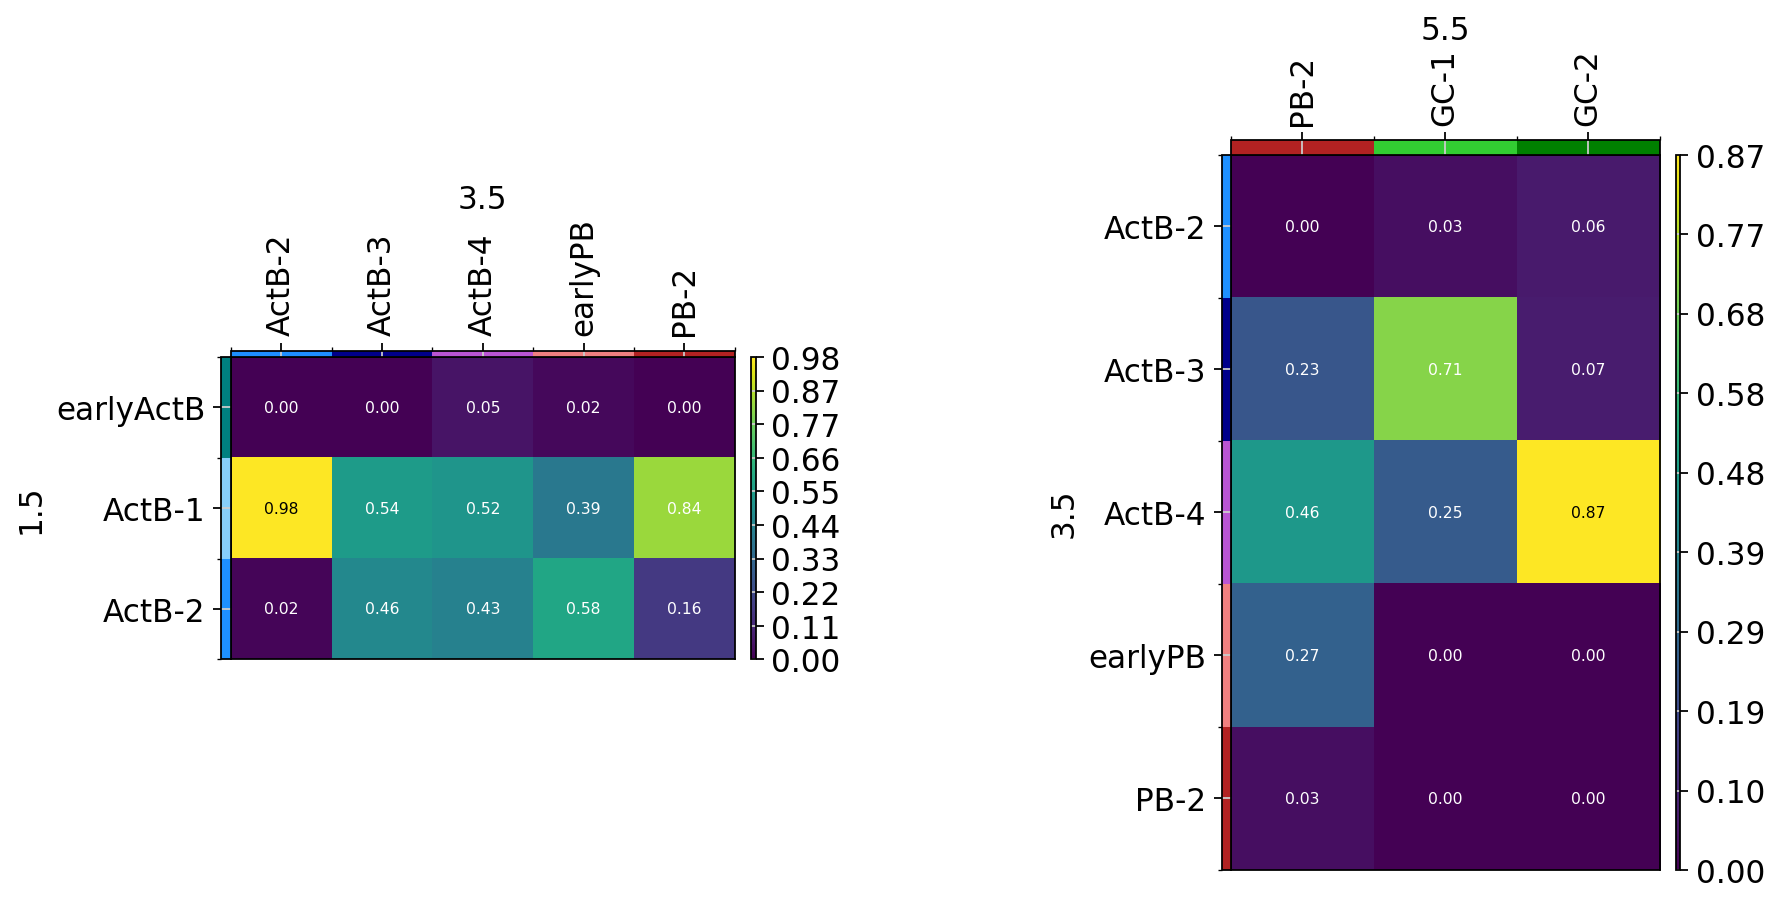

In [40]:
ct_desc = tp0.cell_transition(
    1.5,
    3.5,
    {"sub_cell_type": order_celltypes},
    {"sub_cell_type": order_celltypes},
    forward=False, # ancestor plots
    key_added="transitions_1.5_3.5_large",
)
ct_desc = tp0.cell_transition(
    3.5,
    5.5,
    {"sub_cell_type": order_celltypes},
    {"sub_cell_type": order_celltypes},
    forward=False,
    key_added="transitions_3.5_5.5_large",
)

# Create a 1x2 grid of subplots
fig, axes = plt.subplots(ncols=2, figsize=(12, 6))

axes[0] = mpl.cell_transition(
    tp0,
    fontsize=7,
    figsize=(5, 5),
    return_fig=True,
    ax=axes[0],
    key="transitions_1.5_3.5_large",
)

axes[1] = mpl.cell_transition(
    tp0,
    fontsize=7,
    figsize=(5, 5),
    return_fig=True,
    ax=axes[1],
    key="transitions_3.5_5.5_large",
)


fig.subplots_adjust(wspace=0.8)
# save fig
fig.savefig("/projects/bgdb/asachan/datasets/Bcell_in_vitro_human/figs/ancestor_plots.pdf", dpi=300)


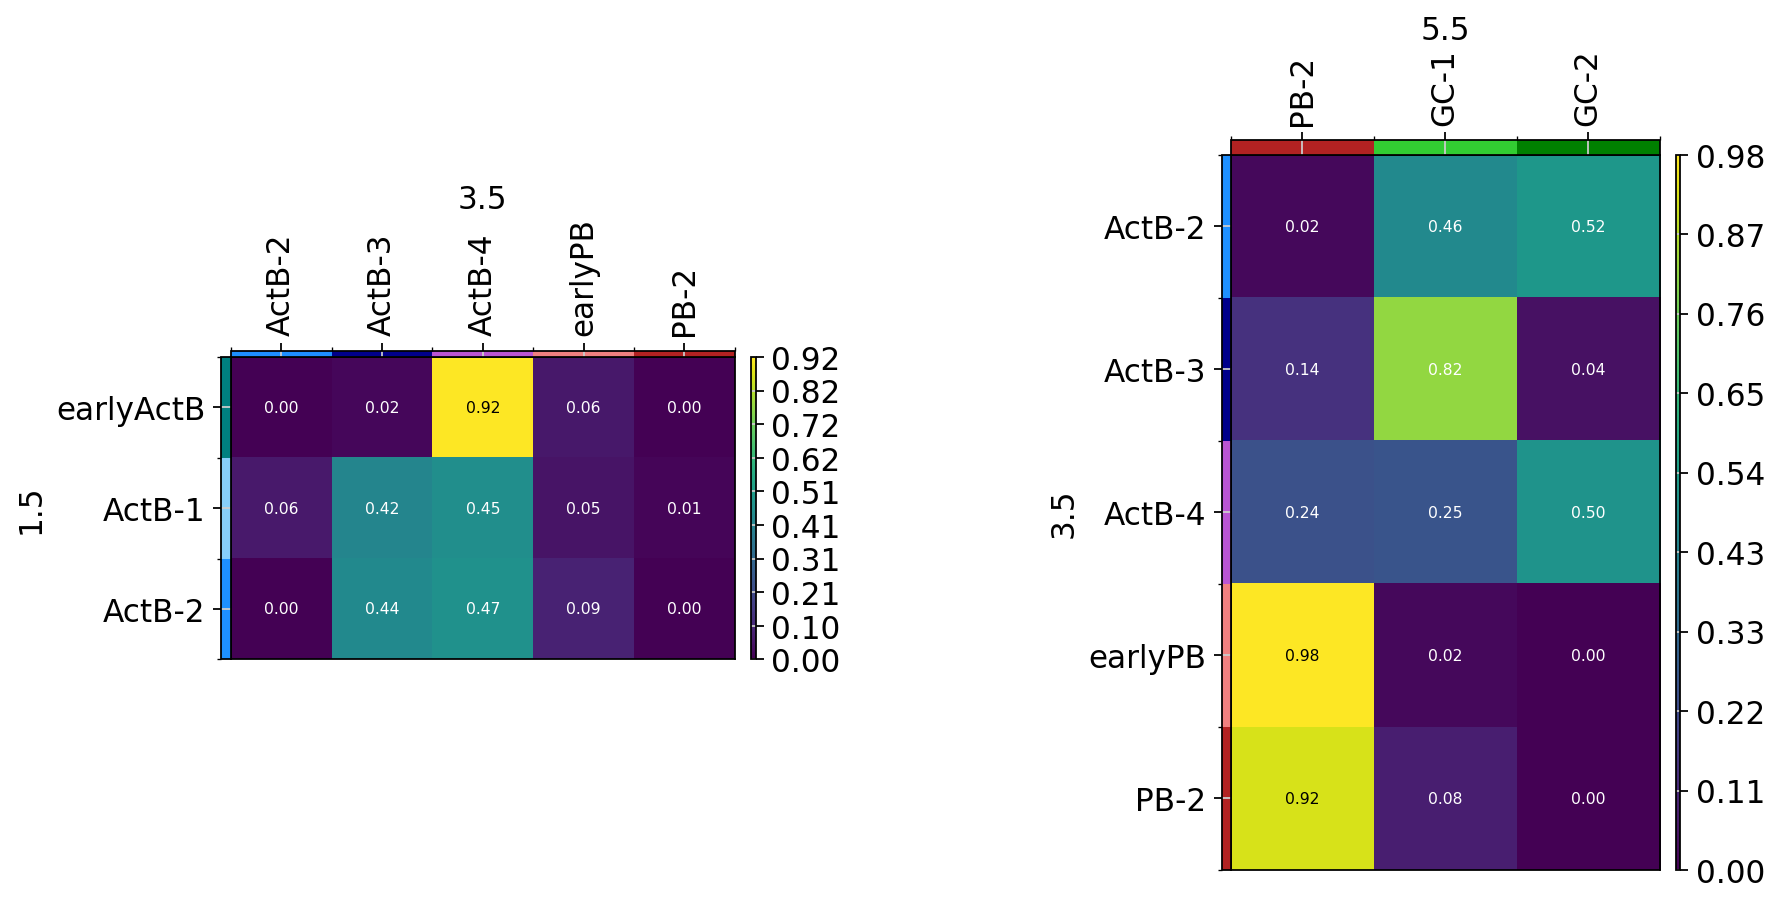

In [41]:
ct_desc = tp0.cell_transition(
    1.5,
    3.5,
    {"sub_cell_type": order_celltypes},
    {"sub_cell_type": order_celltypes},
    forward=True,
    key_added="transitions_1.5_3.5",
)
ct_desc = tp0.cell_transition(
    3.5,
    5.5,
    {"sub_cell_type": order_celltypes},
    {"sub_cell_type": order_celltypes},
    forward=True,
    key_added="transitions_3.5_5.5",
)

# Create a 1x2 grid of subplots
fig, axes = plt.subplots(ncols=2, figsize=(12, 6))

axes[0] = mpl.cell_transition(
    tp0,
    fontsize=7,
    figsize=(5, 5),
    return_fig=True,
    ax=axes[0],
    key="transitions_1.5_3.5",
)

axes[1] = mpl.cell_transition(
    tp0,
    fontsize=7,
    figsize=(5, 5),
    return_fig=True,
    ax=axes[1],
    key="transitions_3.5_5.5",
)


fig.subplots_adjust(wspace=0.8)
# save fig
fig.savefig("/projects/bgdb/asachan/datasets/Bcell_in_vitro_human/figs/descendant_plots.pdf", dpi=300)

W0311 03:58:36.897445 3898038 sol_gpu_cost_model.cc:102] No SoL config found for device: NVIDIA H200. Using default config.
W0311 03:58:37.100900 3898038 sol_gpu_cost_model.cc:102] No SoL config found for device: NVIDIA H200. Using default config.
W0311 03:58:37.118503 3898038 sol_gpu_cost_model.cc:102] No SoL config found for device: NVIDIA H200. Using default config.
W0311 03:58:37.136556 3898038 sol_gpu_cost_model.cc:102] No SoL config found for device: NVIDIA H200. Using default config.
W0311 03:58:37.236334 3898038 sol_gpu_cost_model.cc:102] No SoL config found for device: NVIDIA H200. Using default config.
W0311 03:58:37.281178 3898038 sol_gpu_cost_model.cc:102] No SoL config found for device: NVIDIA H200. Using default config.


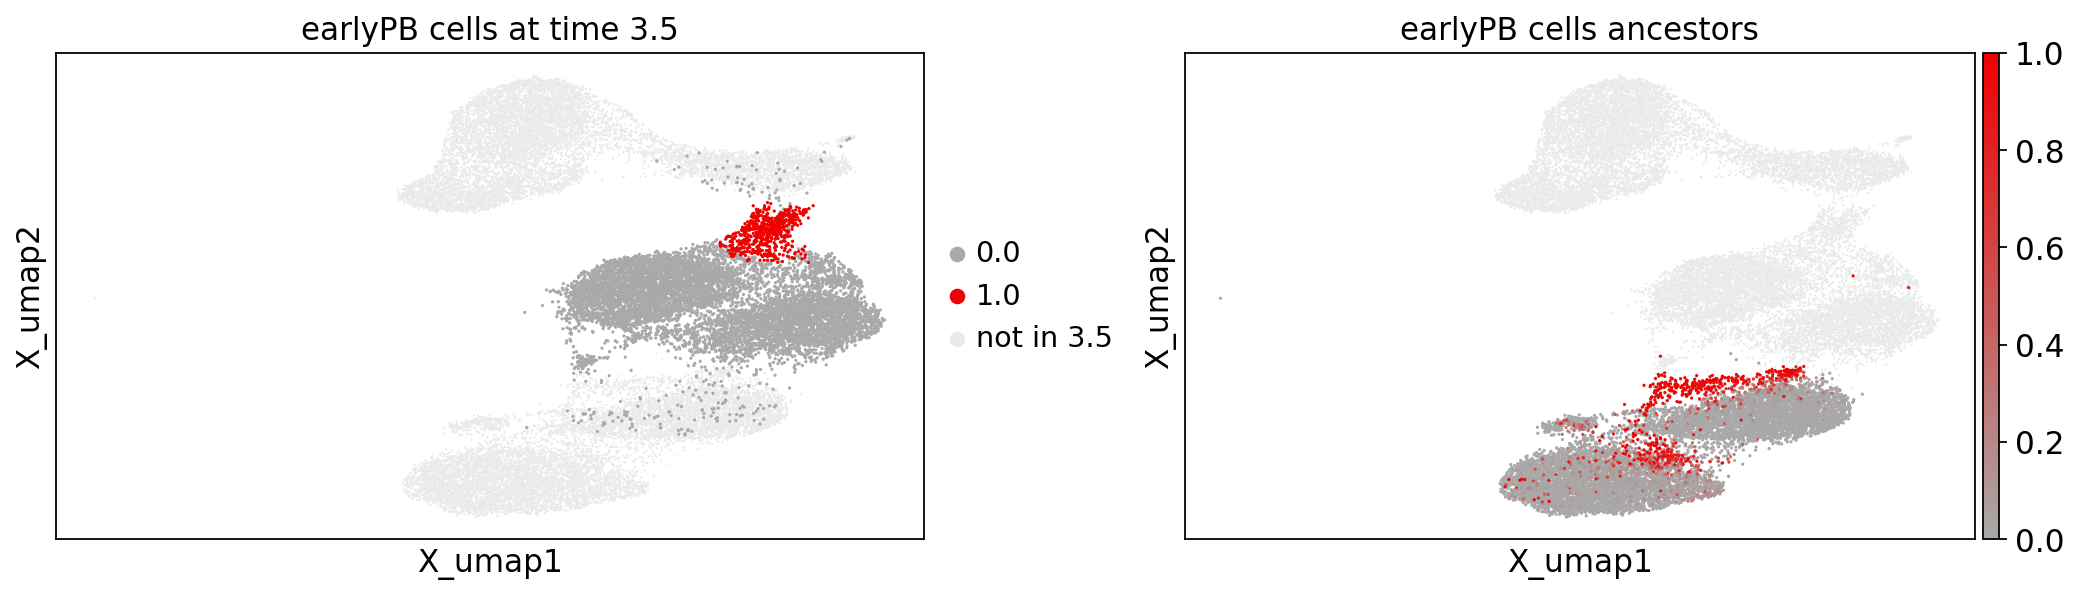

In [31]:
tp0.pull(source=1.5, target=3.5, data="sub_cell_type", subset="earlyPB")
fig, axes = plt.subplots(ncols=2, figsize=(16, 4))

mpl.pull(
    tp0,
    time_points=[3.5],
    basis="X_umap",
    ax=axes[0],
    title=["earlyPB cells at time 3.5"],
)

mpl.pull(
    tp0,
    time_points=[1.5],
    basis="X_umap",
    ax=axes[1],
    title=["earlyPB cells ancestors"],
)

fig.subplots_adjust(wspace=0.3)

In [43]:
tp0.sankey(
    source=3.5,
    target=5.5,
    source_groups={"sub_cell_type": order_celltypes},
    target_groups={"sub_cell_type": order_celltypes},
    threshold=0.05,
    order_annotations=order_celltypes[::-1],
    normalize=True,
)

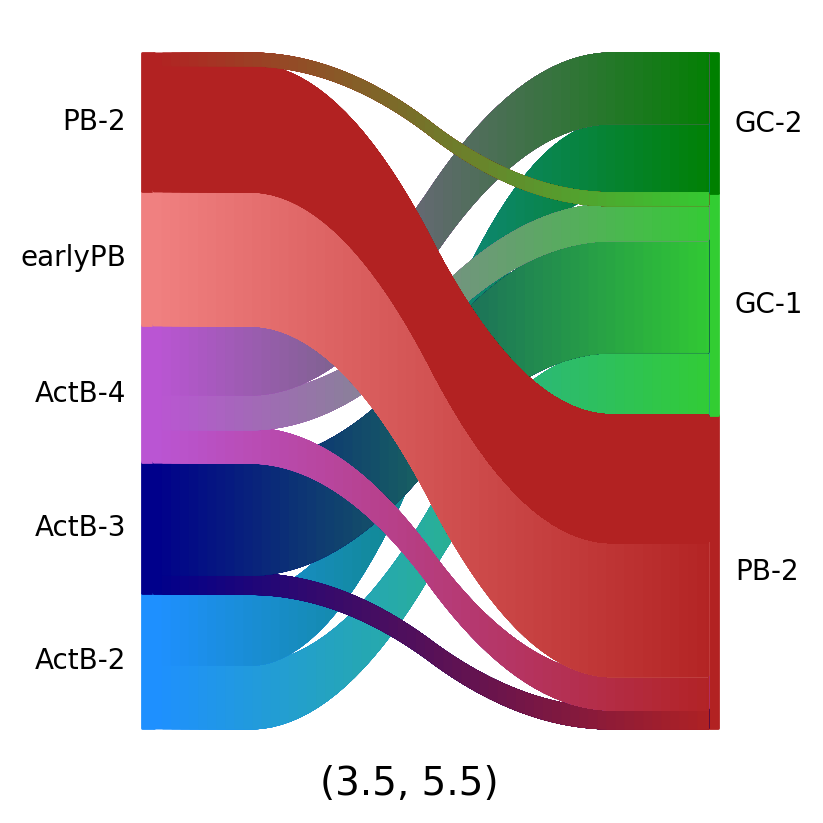

In [44]:
mpl.sankey(tp0, dpi=100, figsize=(4, 4), fontsize=10, interpolate_color=True, save="/projects/bgdb/asachan/datasets/Bcell_in_vitro_human/figs/sankey_3.5_5.5.pdf")

In [45]:
tp0.sankey(
    source=1.5,
    target=3.5,
    source_groups={"sub_cell_type": order_celltypes},
    target_groups={"sub_cell_type": order_celltypes},
    threshold=0.05,
    order_annotations=order_celltypes[::-1],
    normalize=True,
)

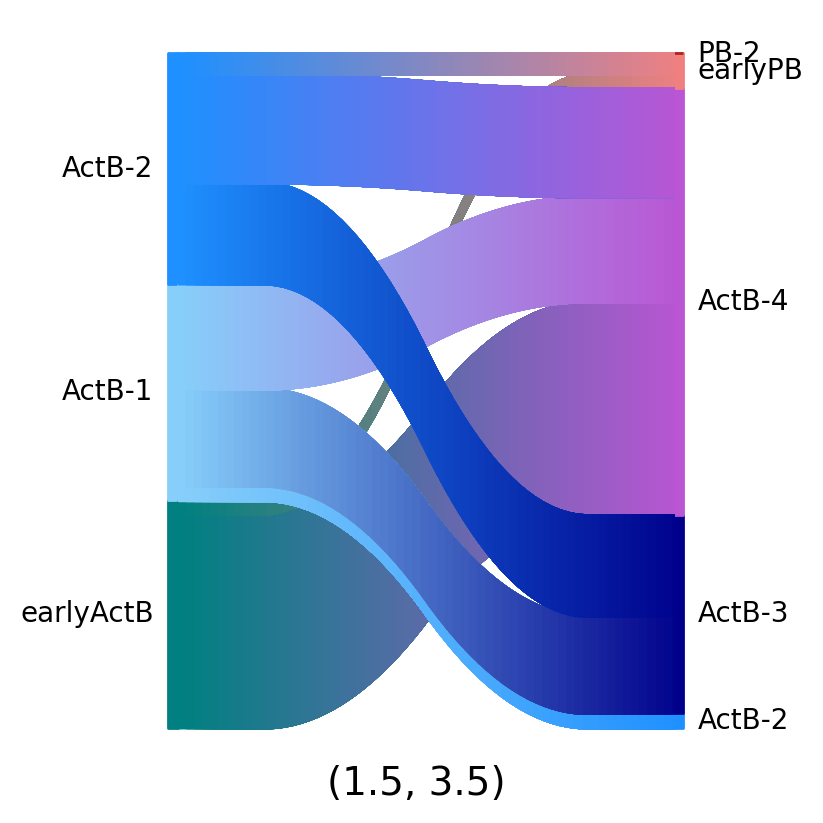

In [46]:
mpl.sankey(tp0, dpi=100, figsize=(4, 4), fontsize=10, interpolate_color=True, save="/projects/bgdb/asachan/datasets/Bcell_in_vitro_human/figs/sankey_1.5_3.5.pdf")

### driver TFs

In [38]:
X_orig = tp0.adata.X.copy()

# 1) Put raw counts into X
tp0.adata.X = tp0.adata.layers["counts"].copy()

# 2) Remove stale flag so scanpy won't warn
tp0.adata.uns.pop("log1p", None)

# 3) Normalize + log1p (now valid because X is counts)
sc.pp.normalize_total(tp0.adata, target_sum=1e4)
sc.pp.log1p(tp0.adata)


In [53]:
def drivers_tf_for_subset(
    tp0,
    subset,
    t_early=(1.5, 3.5),
    t_late=(3.5, 5.5),
    data_key="sub_cell_type",
    features="human",
    obs_key_prefix=None,
    normalize_pull=False,
    corr_annotation=None,
    qval_thresh=0.05,
    corr_thresh=0.1,
):
    prefix = obs_key_prefix if obs_key_prefix is not None else f"{subset[0]}_{subset[1]}"
    key_early = f"{prefix}_pull_early"
    key_late  = f"{prefix}_pull_late"
    key_sum   = f"{prefix}_pull"

    # --- 1. Pull back early transition ---
    tp0.pull(
        t_early[0], t_early[1],
        data=data_key,
        subset=subset[0],
        key_added=key_early,
        normalize=normalize_pull,
    )

    # --- 2. Pull back late transition ---
    tp0.pull(
        t_late[0], t_late[1],
        data=data_key,
        subset=subset[1],
        key_added=key_late,
        normalize=normalize_pull,
    )

    # --- 3. Sum pull weights and validate ---
    tp0.adata.obs[key_sum] = tp0.adata.obs[key_early] + tp0.adata.obs[key_late]

    pull_sum = tp0.adata.obs[key_sum].sum()
    print(f"[pull] key='{key_sum}' | combined weight sum = {pull_sum:.4f}")
    if pull_sum == 0:
        raise ValueError(
            f"All combined pull weights are 0. Check that subsets {subset} exist "
            f"at timepoints {t_early} / {t_late} in obs['{data_key}']."
        )

    # --- 4. Compute feature correlation ---
    drivers = tp0.compute_feature_correlation(
        obs_key=key_sum,
        features=features,
        annotation=corr_annotation,
    )

    # --- 5. Rename columns to be prefix-specific ---
    drivers.columns = [c.replace(key_sum, prefix) for c in drivers.columns]
    corr_col = f"{prefix}_corr"
    qval_col = f"{prefix}_qval"

    # --- 6. Add significance flag and sort ---
    drivers["significant"] = (
        (drivers[qval_col] < qval_thresh) &
        (drivers[corr_col].abs() > corr_thresh)
    )
    drivers = drivers.dropna(subset=[corr_col]).sort_values(corr_col, ascending=False)

    n_sig = drivers["significant"].sum()
    print(f"\n[result] {n_sig} significant drivers "
          f"(qval<{qval_thresh}, |corr|>{corr_thresh})")

    # --- 7. Display top 10 positive and negative drivers ---
    top_pos = drivers.head(10).style.set_caption(
        f"TOP 10 POSITIVE DRIVERS  ({subset[0]} → {subset[1]})"
    ).background_gradient(subset=[corr_col], cmap="Reds")

    top_neg = drivers.tail(10).iloc[::-1].style.set_caption(
        f"TOP 10 NEGATIVE DRIVERS  ({subset[0]} → {subset[1]})"
    ).background_gradient(subset=[corr_col], cmap="Blues_r")

    from IPython.display import display
    display(top_pos)
    display(top_neg)

    return drivers, drivers.head(10), drivers.tail(10).iloc[::-1]

In [54]:
res = drivers_tf_for_subset(
    tp0,
    subset=("ActB-3", "GC-1"),
    t_early=(1.5, 3.5),
    t_late=(3.5, 5.5),
    data_key="sub_cell_type",
    features="human",
    corr_annotation={"cell_type_major": [3.5, 5.5]},
)


[pull] key='ActB-3_GC-1_pull' | combined weight sum = 8261.0009

[result] 38 significant drivers (qval<0.05, |corr|>0.1)


,ActB-3_GC-1_corr,ActB-3_GC-1_pval,ActB-3_GC-1_qval,ActB-3_GC-1_ci_low,ActB-3_GC-1_ci_high,significant
AHR,0.367715,0.000000,0.000000,0.350064,0.385105,True
NFKB1,0.354848,0.000000,0.000000,0.337012,0.372430,True
BATF,0.322278,0.000000,0.000000,0.304003,0.340315,True
SPIB,0.238835,0.000000,0.000000,0.219639,0.257847,True
TCF12,0.229651,0.000000,0.000000,0.210370,0.248753,True
MYC,0.222543,0.000000,0.000000,0.203200,0.241712,True
BATF3,0.204818,0.000000,0.000000,0.185328,0.224148,True
IRF4,0.200517,0.000000,0.000000,0.180993,0.219882,True
ZBTB7A,0.191452,0.000000,0.000000,0.171860,0.210893,True
PBX3,0.185655,0.000000,0.000000,0.166021,0.205143,True


,ActB-3_GC-1_corr,ActB-3_GC-1_pval,ActB-3_GC-1_qval,ActB-3_GC-1_ci_low,ActB-3_GC-1_ci_high,significant
IKZF2,-0.283354,0.000000,0.000000,-0.301880,-0.264614,True
ZBTB20,-0.257013,0.000000,0.000000,-0.275836,-0.237994,True
STAT4,-0.126952,0.000000,0.000000,-0.146834,-0.106968,True
NR3C2,-0.121736,0.000000,0.000000,-0.141646,-0.101728,True
BHLHE41,-0.108397,0.000000,0.000000,-0.128375,-0.088332,True
ZNF248,-0.108005,0.000000,0.000000,-0.127984,-0.087938,True
BCL6,-0.097179,0.000000,0.000000,-0.117207,-0.077071,False
MXI1,-0.084615,0.000000,0.000000,-0.104694,-0.064466,False
MBNL2,-0.084599,0.000000,0.000000,-0.104678,-0.064450,False
PRDM1,-0.084024,0.000000,0.000000,-0.104106,-0.063873,False


In [56]:
res = drivers_tf_for_subset(
    tp0,
    subset=("ActB-4", "GC-1"),
    t_early=(1.5, 3.5),
    t_late=(3.5, 5.5),
    data_key="sub_cell_type",
    features="human",
    corr_annotation={"cell_type_major": [3.5, 5.5]},
)


[pull] key='ActB-4_GC-1_pull' | combined weight sum = 8786.0009

[result] 37 significant drivers (qval<0.05, |corr|>0.1)


,ActB-4_GC-1_corr,ActB-4_GC-1_pval,ActB-4_GC-1_qval,ActB-4_GC-1_ci_low,ActB-4_GC-1_ci_high,significant
IKZF2,0.424691,0.000000,0.000000,0.407941,0.441154,True
STAT4,0.256729,0.000000,0.000000,0.237706,0.275555,True
PAX5,0.244930,0.000000,0.000000,0.225791,0.263879,True
BCL6,0.191313,0.000000,0.000000,0.171719,0.210755,True
ZEB2,0.190853,0.000000,0.000000,0.171256,0.210299,True
HNF1B,0.180449,0.000000,0.000000,0.160778,0.199977,True
PLAGL1,0.180112,0.000000,0.000000,0.160438,0.199642,True
TCF7L2,0.171193,0.000000,0.000000,0.151459,0.190790,True
TRPS1,0.153466,0.000000,0.000000,0.133623,0.173187,True
RUNX1,0.147954,0.000000,0.000000,0.128079,0.167710,True


,ActB-4_GC-1_corr,ActB-4_GC-1_pval,ActB-4_GC-1_qval,ActB-4_GC-1_ci_low,ActB-4_GC-1_ci_high,significant
PRDM1,-0.442974,0.000000,0.000000,-0.459113,-0.426543,True
BHLHE41,-0.246409,0.000000,0.000000,-0.265343,-0.227284,True
XBP1,-0.221803,0.000000,0.000000,-0.240979,-0.202454,True
RUNX2,-0.212674,0.000000,0.000000,-0.231934,-0.193248,True
POU2AF1,-0.191827,0.000000,0.000000,-0.211265,-0.172237,True
SOX2,-0.164199,0.000000,0.000000,-0.183847,-0.144420,True
ATF5,-0.144638,0.000000,0.000000,-0.164415,-0.124744,True
MBNL2,-0.141196,0.000000,0.000000,-0.160995,-0.121284,True
ELK3,-0.136883,0.000000,0.000000,-0.156708,-0.116949,True
ESR1,-0.127924,0.000000,0.000000,-0.147800,-0.107945,True


In [57]:
res = drivers_tf_for_subset(
    tp0,
    subset=("ActB-4", "GC-2"),
    t_early=(1.5, 3.5),
    t_late=(3.5, 5.5),
    data_key="sub_cell_type",
    features="human",
    corr_annotation={"cell_type_major": [3.5, 5.5]},
)


[pull] key='ActB-4_GC-2_pull' | combined weight sum = 6915.9992

[result] 39 significant drivers (qval<0.05, |corr|>0.1)


,ActB-4_GC-2_corr,ActB-4_GC-2_pval,ActB-4_GC-2_qval,ActB-4_GC-2_ci_low,ActB-4_GC-2_ci_high,significant
IKZF2,0.495495,0.000000,0.000000,0.480055,0.510629,True
ZBTB20,0.257010,0.000000,0.000000,0.237990,0.275833,True
STAT4,0.248497,0.000000,0.000000,0.229392,0.267410,True
BCL6,0.216996,0.000000,0.000000,0.197605,0.236217,True
NR3C2,0.182471,0.000000,0.000000,0.162814,0.201983,True
PAX5,0.157169,0.000000,0.000000,0.137347,0.176865,True
RUNX1,0.148366,0.000000,0.000000,0.128493,0.168119,True
NR4A3,0.128738,0.000000,0.000000,0.108763,0.148610,True
MXI1,0.128432,0.000000,0.000000,0.108456,0.148306,True
ZNF831,0.113844,0.000000,0.000000,0.093801,0.133795,True


,ActB-4_GC-2_corr,ActB-4_GC-2_pval,ActB-4_GC-2_qval,ActB-4_GC-2_ci_low,ActB-4_GC-2_ci_high,significant
PRDM1,-0.299095,0.000000,0.000000,-0.317430,-0.280535,True
IRF4,-0.298634,0.000000,0.000000,-0.316976,-0.280070,True
BATF,-0.282180,0.000000,0.000000,-0.300720,-0.263427,True
AHR,-0.274655,0.000000,0.000000,-0.293283,-0.255820,True
NFKB1,-0.258136,0.000000,0.000000,-0.276947,-0.239128,True
RUNX2,-0.238940,0.000000,0.000000,-0.257950,-0.219744,True
TCF12,-0.232110,0.000000,0.000000,-0.251188,-0.212852,True
ESR1,-0.232079,0.000000,0.000000,-0.251157,-0.212821,True
XBP1,-0.218959,0.000000,0.000000,-0.238161,-0.199585,True
RELB,-0.188710,0.000000,0.000000,-0.208173,-0.169097,True


In [60]:
res = drivers_tf_for_subset(
    tp0,
    subset=("ActB-4", "PB-2"),
    t_early=(1.5, 3.5),
    t_late=(3.5, 5.5),
    data_key="sub_cell_type",
    features="human",
    corr_annotation={"cell_type_major": [3.5, 5.5]},
)


[pull] key='ActB-4_PB-2_pull' | combined weight sum = 6683.9989

[result] 31 significant drivers (qval<0.05, |corr|>0.1)


,ActB-4_PB-2_corr,ActB-4_PB-2_pval,ActB-4_PB-2_qval,ActB-4_PB-2_ci_low,ActB-4_PB-2_ci_high,significant
IKZF2,0.316903,0.000000,0.000000,0.298561,0.335012,True
ZBTB20,0.209319,0.000000,0.000000,0.189865,0.228608,True
STAT4,0.178710,0.000000,0.000000,0.159026,0.198251,True
BCL6,0.137329,0.000000,0.000000,0.117397,0.157151,True
NR3C2,0.123846,0.000000,0.000000,0.103847,0.143744,True
ZNF248,0.111163,0.000000,0.000000,0.091109,0.131126,True
H1FX,0.108078,0.000000,0.000000,0.088012,0.128057,True
TFEC,0.105521,0.000000,0.000000,0.085444,0.125511,True
PHF21A,0.102980,0.000000,0.000000,0.082894,0.122983,True
NR4A3,0.089696,0.000000,0.000000,0.069563,0.109756,False


,ActB-4_PB-2_corr,ActB-4_PB-2_pval,ActB-4_PB-2_qval,ActB-4_PB-2_ci_low,ActB-4_PB-2_ci_high,significant
NFKB1,-0.272094,0.000000,0.000000,-0.290750,-0.253231,True
BATF,-0.259052,0.000000,0.000000,-0.277853,-0.240053,True
AHR,-0.254587,0.000000,0.000000,-0.273436,-0.235543,True
SPIB,-0.172985,0.000000,0.000000,-0.192569,-0.153263,True
MYC,-0.171115,0.000000,0.000000,-0.190713,-0.151381,True
TCF12,-0.170734,0.000000,0.000000,-0.190335,-0.150997,True
ZBTB7A,-0.148711,0.000000,0.000000,-0.168462,-0.128840,True
BATF3,-0.148014,0.000000,0.000000,-0.167770,-0.128139,True
SP4,-0.137294,0.000000,0.000000,-0.157116,-0.117361,True
RELB,-0.134328,0.000000,0.000000,-0.154167,-0.114380,True
